# Example notebook

In [3]:
%matplotlib inline
from skimage import transform
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from floortrans.models import get_model
from floortrans.loaders import FloorplanSVG, DictToTensor, Compose, RotateNTurns
from floortrans.plotting import segmentation_plot, polygons_to_image, draw_junction_from_dict, discrete_cmap
discrete_cmap()
from floortrans.post_prosessing import split_prediction, get_polygons, split_validation
from floortrans.losses import UncertaintyLoss
from floortrans.metrics import runningScore, pixel_accuracy
from mpl_toolkits.axes_grid1 import AxesGrid

rot = RotateNTurns()
room_classes = ["Background", "Outdoor", "Wall", "Kitchen", "Living Room" ,"Bed Room", "Bath", "Entry", "Railing", "Storage", "Garage", "Undefined"]

data_folder = 'data/cubicasa5k/'
data_file = 'test.txt'
normal_set = FloorplanSVG(data_folder, data_file, format='txt', original_size=True)
data_loader = DataLoader(normal_set, batch_size=1, num_workers=0)
data_iter = iter(data_loader)
# Setup Model
model = get_model('hg_furukawa_original', 51)

n_classes = 33  # 21 heatmaps + 12 rooms (icon removed)
split = [21, 12]
model.conv4_ = torch.nn.Conv2d(256, n_classes, bias=True, kernel_size=1)
model.upsample = torch.nn.ConvTranspose2d(n_classes, n_classes, kernel_size=4, stride=4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load("model_best_val_loss_var.pkl", weights_only=False)
model.to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()

# Criterion for loss computation (room/wall only)
criterion = UncertaintyLoss(input_slice=split, cuda=(device.type == 'cuda'))
if 'criterion_state' in checkpoint:
    criterion.load_state_dict(checkpoint['criterion_state'])
criterion.to(device)
criterion.eval()

print("Model loaded.")

RuntimeError: Error(s) in loading state_dict for hg_furukawa_original:
	size mismatch for conv4_.weight: copying a param with shape torch.Size([33, 256, 1, 1]) from checkpoint, the shape in current model is torch.Size([44, 256, 1, 1]).
	size mismatch for conv4_.bias: copying a param with shape torch.Size([33]) from checkpoint, the shape in current model is torch.Size([44]).
	size mismatch for upsample.weight: copying a param with shape torch.Size([33, 33, 4, 4]) from checkpoint, the shape in current model is torch.Size([44, 44, 4, 4]).
	size mismatch for upsample.bias: copying a param with shape torch.Size([33]) from checkpoint, the shape in current model is torch.Size([44]).

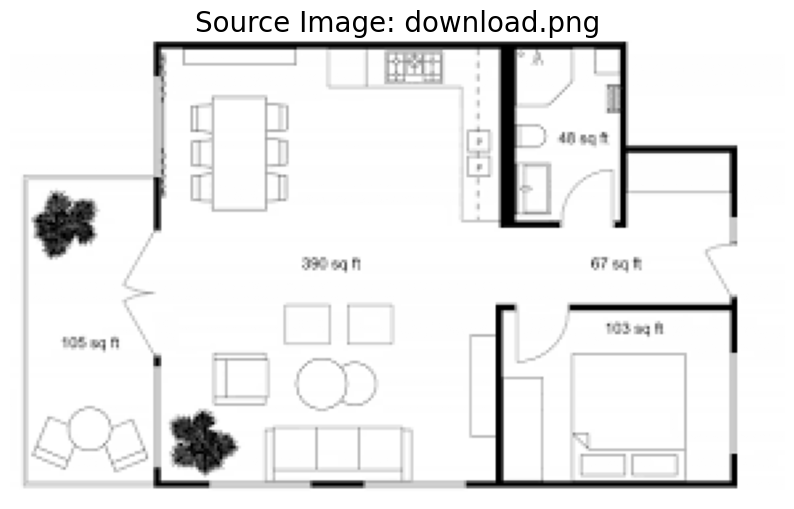

In [4]:
# --- Original: load next sample from dataset ---
# val = next(data_iter)
# junctions = val['heatmaps']
# folder = val['folder'][0]
# image = val['image'].to(device)
# label = val['label']
# np_img = np.moveaxis(image[0].cpu().data.numpy(), 0, -1) / 2 + 0.5
# plt.figure(figsize=(10,10))
# plt.title('Source Image', fontsize=20)
# plt.axis('off')
# plt.imshow(np_img)
# plt.show()

# --- Load a single image for inference (no ground-truth label) ---
import cv2

IMAGE_PATH = "download.png"

fplan = cv2.imread(IMAGE_PATH)
fplan = cv2.cvtColor(fplan, cv2.COLOR_BGR2RGB)
height, width, _ = fplan.shape
img_size = (height, width)

# Normalise to [-1, 1] (same as training)
fplan_norm = 2 * (fplan.astype(np.float32) / 255.0) - 1
img_tensor = torch.FloatTensor(np.moveaxis(fplan_norm, -1, 0)).unsqueeze(0).to(device)

image  = img_tensor          # shape: [1, 3, H, W]
label  = None                # no ground-truth for a raw image
junctions = {i: [] for i in range(21)}   # empty heatmap dict
folder = IMAGE_PATH

np_img = fplan.astype(np.float32) / 255.0  # for display

plt.figure(figsize=(10, 10))
plt.title('Source Image: ' + IMAGE_PATH, fontsize=20)
plt.axis('off')
plt.imshow(np_img)
plt.show()

## The SVG floorplan
If the floorplan includes two floors the other floor might not be visible, but it will be parsed never the less.

In [8]:
from IPython.display import Image
from IPython.core.display import HTML
if label is not None:
    Image(url=data_folder+folder+"model.svg", width=800)
else:
    print("SVG floor plan not available in inference-only mode (no dataset folder).")

SVG floor plan not available in inference-only mode (no dataset folder).


## Parsed labels

No ground-truth label available (inference-only mode).


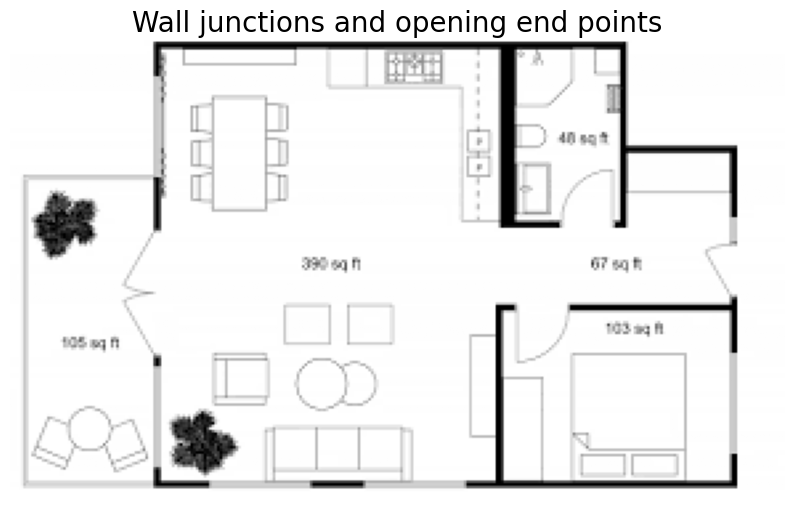

In [ ]:
n_rooms = 12  # always defined for downstream cells
n_label_ch = None

if label is not None:
    label_np = label.data.numpy()[0]
    n_label_ch = label.shape[0]
    plt.figure(figsize=(10,10))
    ax = plt.subplot(1, 1, 1)
    plt.title('Rooms and walls', fontsize=20)
    ax.axis('off')
    rseg = ax.imshow(label_np[0], cmap='rooms', vmin=0, vmax=n_rooms-0.1)
    cbar = plt.colorbar(rseg, ticks=np.arange(n_rooms) + 0.5, fraction=0.046, pad=0.01)
    cbar.ax.set_yticklabels(room_classes, fontsize=20)
    plt.show()
else:
    label_np = None
    print("No ground-truth label available (inference-only mode).")

plt.figure(figsize=(10,10))
ax = plt.subplot(1, 1, 1)
plt.title('Wall junctions and opening end points', fontsize=20)
ax.axis('off')
ax.imshow(np_img)
h, w, _ = np_img.shape
draw_junction_from_dict(junctions, w, h, size=0.3, fontsize=10)
plt.show()

## Networks prediction for the segmentation

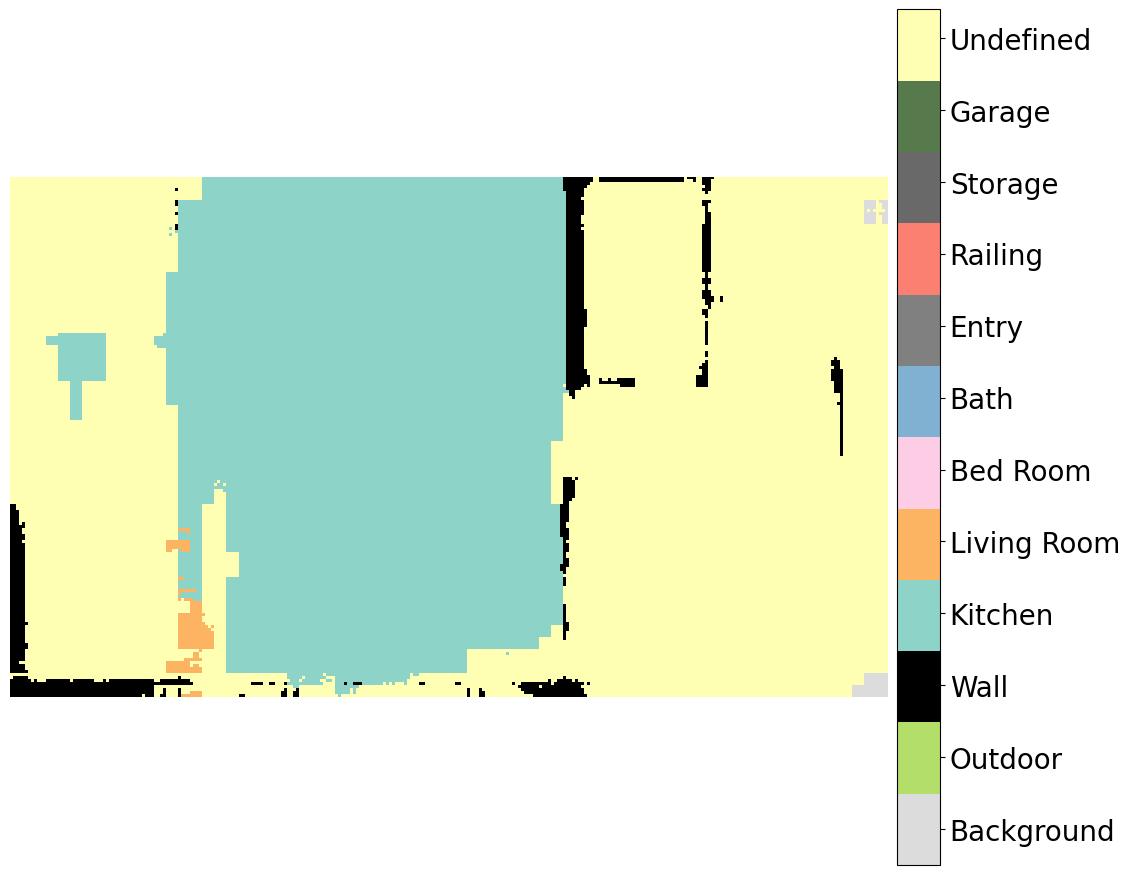

In [12]:
with torch.no_grad():
    n_rooms = 12  # fallback in case cell 6 was skipped
    if label_np is not None:
        height = label_np.shape[1]
        width = label_np.shape[2]
        img_size = (height, width)
    # else: height/width/img_size already set by the image loading cell
    
    rotations = [(0, 0), (1, -1), (2, 2), (-1, 1)]
    pred_count = len(rotations)
    prediction = torch.zeros([pred_count, n_classes, height, width])
    for i, r in enumerate(rotations):
        forward, back = r
        # We rotate first the image
        rot_image = rot(image, 'tensor', forward)
        pred = model(rot_image)
        # We rotate prediction back
        pred = rot(pred, 'tensor', back)
        # We fix heatmaps
        pred = rot(pred, 'points', back)
        # We make sure the size is correct
        pred = F.interpolate(pred, size=(height, width), mode='bilinear', align_corners=True)
        # We add the prediction to output
        prediction[i] = pred[0]

prediction = torch.mean(prediction, 0, True)

rooms_pred = F.softmax(prediction[0, 21:21+12], 0).cpu().data.numpy()
rooms_pred = np.argmax(rooms_pred, axis=0)

plt.figure(figsize=(12,12))
ax = plt.subplot(1, 1, 1)
ax.axis('off')
rseg = ax.imshow(rooms_pred, cmap='rooms', vmin=0, vmax=n_rooms-0.1)
cbar = plt.colorbar(rseg, ticks=np.arange(n_rooms) + 0.5, fraction=0.046, pad=0.01)
cbar.ax.set_yticklabels(room_classes, fontsize=20)
plt.show()

## Loss and accuracy (current sample)

In [13]:
if label_np is not None:
    # Room (wall) segmentation only: loss and accuracy
    n_label_ch = label.shape[0]
    room_gt_idx = 0 if n_label_ch == 2 else min(21, n_label_ch-1)
    room_gt = label_np[room_gt_idx].astype(np.int32)
    room_gt = np.clip(room_gt, 0, n_rooms - 1)

    # Loss: room cross-entropy only
    rooms_logits = prediction[:, 21:21+12, :, :].to(device)
    room_gt_t = torch.from_numpy(room_gt).long().unsqueeze(0).to(device)
    with torch.no_grad():
        sample_loss = F.cross_entropy(rooms_logits, room_gt_t)
    print("Room segmentation loss: {:.4f}".format(sample_loss.item()))

    # Pixel accuracy
    room_acc = pixel_accuracy(room_gt, rooms_pred)
    print("Room pixel accuracy: {:.2%}".format(room_acc))

    # Overall segmentation metrics (Overall Acc, Mean Acc, Mean IoU) for this sample
    score_room = runningScore(n_rooms)
    score_room.update([room_gt], [rooms_pred])
    room_scores, _ = score_room.get_scores()
    print("Room - Overall Acc: {:.2%}, Mean Acc: {:.2%}, Mean IoU: {:.2%}".format(
        room_scores["Overall Acc"], room_scores["Mean Acc"], room_scores["Mean IoU"]))
else:
    print("Metrics skipped — no ground-truth label in inference-only mode.")

Metrics skipped — no ground-truth label in inference-only mode.


## Post-processed polygons

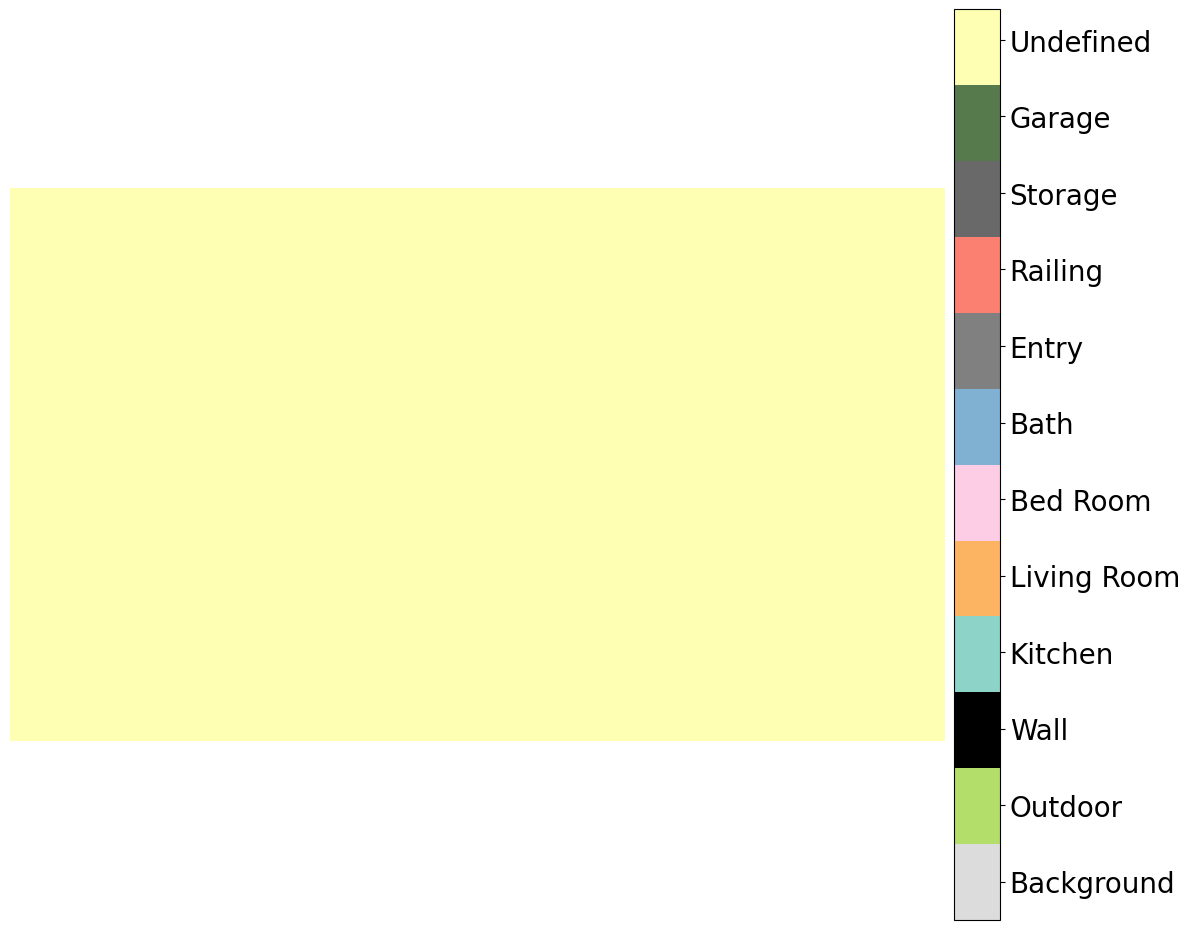

In [14]:

heatmaps, rooms = split_prediction(prediction, img_size, split)
polygons, types, room_polygons, room_types = get_polygons((heatmaps, rooms), 0.2, [1, 2])

pol_room_seg = polygons_to_image(polygons, types, room_polygons, room_types, height, width)
plt.figure(figsize=(12,12))
ax = plt.subplot(1, 1, 1)
ax.axis('off')
rseg = ax.imshow(pol_room_seg, cmap='rooms', vmin=0, vmax=n_rooms-0.1)
cbar = plt.colorbar(rseg, ticks=np.arange(n_rooms) + 0.5, fraction=0.046, pad=0.01)
cbar.ax.set_yticklabels(room_classes, fontsize=20)
plt.tight_layout()
plt.show()

## Ground truth and prediction comparisons

In [17]:
if label_np is not None:
    fig = plt.figure(figsize=(26, 12))
    grid = AxesGrid(fig, 111,
                    nrows_ncols=(1, 2),
                    axes_pad=0.05,
                    cbar_mode='single',
                    cbar_location='right',
                    cbar_pad=0.1
                    )
    room_gt_idx = 0 if label_np.shape[0] == 2 else min(21, n_label_ch-1)
    images = [label_np[room_gt_idx], pol_room_seg]
    for i, ax in enumerate(grid):
        ax.set_axis_off()
        im = ax.imshow(images[i], cmap='rooms', vmin=0, vmax=n_rooms-0.1)
    cbar = ax.cax.colorbar(rseg, ticks=np.arange(n_rooms) + 0.5)
    cbar.ax.set_yticklabels(room_classes, fontsize=26)
    plt.show()
else:
    print("GT vs prediction comparison skipped — no ground-truth label.")

GT vs prediction comparison skipped — no ground-truth label.


In [ ]:
# Icon comparison removed — notebook shows room/wall segmentation only.

## Run inference and save results for evaluation

Run the cell below to save all outputs (input image, ground truth, predictions, room polygons) to a folder so you can inspect and evaluate the model.

In [22]:
import os
import json

# Output directory for saved results (one subfolder per test sample)
save_dir = os.path.join('saved_results', folder.replace('/', '_'))
os.makedirs(save_dir, exist_ok=True)

# 1. Save input image
plt.imsave(os.path.join(save_dir, '01_input.png'), np_img)
# 2. Save ground truth room segmentation (only when label is available)
if label_np is not None:
    room_gt_idx = 0 if label_np.shape[0] == 2 else min(21, n_label_ch-1)
    plt.imsave(os.path.join(save_dir, '02_ground_truth_rooms.png'),
               label_np[room_gt_idx], cmap='rooms', vmin=0, vmax=n_rooms-0.1)
# 3. Save raw model prediction (room segmentation)
plt.imsave(os.path.join(save_dir, '03_predicted_rooms.png'), rooms_pred, cmap='rooms', vmin=0, vmax=n_rooms-0.1)
# 4. Save post-processed polygon room segmentation
plt.imsave(os.path.join(save_dir, '04_polygon_rooms.png'), pol_room_seg, cmap='rooms', vmin=0, vmax=n_rooms-0.1)

# 5. Save room polygons as JSON for downstream use / evaluation
room_polygons_export = []
for i, poly in enumerate(room_polygons):
    class_idx = room_types[i]['class'] if i < len(room_types) else 0
    room_name = room_classes[class_idx] if class_idx < len(room_classes) else str(class_idx)
    room_polygons_export.append({
        'room_index': i,
        'room_class': class_idx,
        'room_name': room_name,
        'polygon_xy': poly.tolist() if hasattr(poly, 'tolist') else list(poly)
    })
with open(os.path.join(save_dir, '05_room_polygons.json'), 'w') as f:
    json.dump(room_polygons_export, f, indent=2)

# 6. Save side-by-side comparison figure (GT vs prediction)
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].set_title('Ground truth')
axes[0].imshow(label_np[room_gt_idx], cmap='rooms', vmin=0, vmax=n_rooms-0.1)
axes[0].axis('off')
axes[1].set_title('Prediction (post-processed)')
axes[1].imshow(pol_room_seg, cmap='rooms', vmin=0, vmax=n_rooms-0.1)
axes[1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, '06_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Results saved to: {os.path.abspath(save_dir)}")
print(f"  - 01_input.png, 02_ground_truth_rooms.png, 03_predicted_rooms.png")
print(f"  - 04_polygon_rooms.png, 05_room_polygons.json, 06_comparison.png")

TypeError: 'MultiPolygon' object is not iterable

In [ ]:
if label_np is not None:
    fig = plt.figure(figsize=(26, 12))
    grid = AxesGrid(fig, 111,
                    nrows_ncols=(1, 2),
                    axes_pad=0.05,
                    cbar_mode='single',
                    cbar_location='right',
                    cbar_pad=0.1
                    )
    room_gt_idx = 0 if label_np.shape[0] == 2 else 21
    images = [label_np[room_gt_idx], pol_room_seg]
    for i, ax in enumerate(grid):
        ax.set_axis_off()
        im = ax.imshow(images[i], cmap='rooms', vmin=0, vmax=n_rooms-0.1)
    cbar = ax.cax.colorbar(rseg, ticks=np.arange(n_rooms) + 0.5)
    cbar.ax.set_yticklabels(room_classes, fontsize=26)
    plt.show()
else:
    print("GT vs prediction comparison skipped — no ground-truth label.")

In [ ]:
# Icon comparison removed — notebook shows room/wall segmentation only.

## Run inference and save results for evaluation

Run the cell below to save all outputs (input image, ground truth, predictions, room polygons) to a folder so you can inspect and evaluate the model.

In [ ]:
import os
import json

# Output directory for saved results (one subfolder per test sample)
save_dir = os.path.join('saved_results', folder.replace('/', '_'))
os.makedirs(save_dir, exist_ok=True)

# 1. Save input image
plt.imsave(os.path.join(save_dir, '01_input.png'), np_img)
# 2. Save ground truth room segmentation (only when label is available)
if label_np is not None:
    room_gt_idx = 0 if label_np.shape[0] == 2 else 21
    plt.imsave(os.path.join(save_dir, '02_ground_truth_rooms.png'),
               label_np[room_gt_idx], cmap='rooms', vmin=0, vmax=n_rooms-0.1)
# 3. Save raw model prediction (room segmentation)
plt.imsave(os.path.join(save_dir, '03_predicted_rooms.png'), rooms_pred, cmap='rooms', vmin=0, vmax=n_rooms-0.1)
# 4. Save post-processed polygon room segmentation
plt.imsave(os.path.join(save_dir, '04_polygon_rooms.png'), pol_room_seg, cmap='rooms', vmin=0, vmax=n_rooms-0.1)

# 5. Save room polygons as JSON for downstream use / evaluation
room_polygons_export = []
for i, poly in enumerate(room_polygons):
    class_idx = room_types[i]['class'] if i < len(room_types) else 0
    room_name = room_classes[class_idx] if class_idx < len(room_classes) else str(class_idx)
    room_polygons_export.append({
        'room_index': i,
        'room_class': class_idx,
        'room_name': room_name,
        'polygon_xy': poly.tolist() if hasattr(poly, 'tolist') else list(poly)
    })
with open(os.path.join(save_dir, '05_room_polygons.json'), 'w') as f:
    json.dump(room_polygons_export, f, indent=2)

# 6. Save side-by-side comparison figure (GT vs prediction)
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].set_title('Ground truth')
axes[0].imshow(label_np[room_gt_idx], cmap='rooms', vmin=0, vmax=n_rooms-0.1)
axes[0].axis('off')
axes[1].set_title('Prediction (post-processed)')
axes[1].imshow(pol_room_seg, cmap='rooms', vmin=0, vmax=n_rooms-0.1)
axes[1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, '06_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Results saved to: {os.path.abspath(save_dir)}")
print(f"  - 01_input.png, 02_ground_truth_rooms.png, 03_predicted_rooms.png")
print(f"  - 04_polygon_rooms.png, 05_room_polygons.json, 06_comparison.png")